# The Skill Decay vs. Skill Augmentation Paradox — Data Scientists Edition
## Has AI Made Data Scientists More Powerful or More Dependent? (2021–2025)

---

> **Research Question:** As AutoML, LLM-assisted EDA, and pre-trained model APIs become the default toolkit, are data scientists deepening their statistical and mathematical intuition — or are they becoming sophisticated API callers who can no longer build from first principles?

**Project Pipeline:**
1. Data Simulation & Scraping Template (Kaggle / GitHub DS notebooks)
2. Exploratory Data Analysis (EDA)
3. Machine Learning — AI-Assistance Detection & DS Persona Segmentation
4. Statistical Testing
5. Executive Summary

**Dataset:** 10,000 synthetic data science project submissions modeled on real-world Kaggle, GitHub, and enterprise DS workflow trends (2021–2025)

---
## Section 0 — Environment Setup

In [25]:
import warnings
warnings.filterwarnings('ignore')

# --- Core ---
import numpy as np
import pandas as pd
from datetime import datetime, timedelta
import random

# --- Visualization ---
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns

# --- Machine Learning ---
from sklearn.ensemble import RandomForestRegressor, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, classification_report
from sklearn.decomposition import PCA

# --- Statistics ---
from scipy import stats
from scipy.stats import pearsonr

# --- Web Scraping (template) ---
import requests
from bs4 import BeautifulSoup
import time

# --- Global Style ---
sns.set_theme(style='darkgrid', palette='deep')
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print(f"✓ Environment ready.")
print(f"  NumPy  : {np.__version__}")
print(f"  Pandas : {pd.__version__}")
print(f"  Seaborn: {sns.__version__}")

✓ Environment ready.
  NumPy  : 1.26.4
  Pandas : 2.2.2
  Seaborn: 0.13.2


---
## Section 1 — Data Acquisition
### 1A. Scraping Template — Kaggle Notebooks & GitHub DS Repos

In [26]:
# ============================================================
# SCRAPING TEMPLATE — Kaggle Public API + GitHub REST API
# ============================================================
# Kaggle exposes a public API at https://www.kaggle.com/api/v1
# GitHub exposes notebook metadata at https://api.github.com
# Set DRY_RUN = False and provide your tokens to activate.
# ============================================================

DRY_RUN = True

KAGGLE_API_BASE  = "https://www.kaggle.com/api/v1"
GITHUB_API_BASE  = "https://api.github.com"

HEADERS_KAGGLE = {
    "User-Agent" : "research-bot",
    "Content-Type": "application/json",
    # Add: "Authorization": "Basic <base64(username:api_key)>"
}
HEADERS_GITHUB = {
    "User-Agent"   : "research-bot",
    "Accept"       : "application/vnd.github+json",
    # Add: "Authorization": "Bearer <your_github_token>"
}


def fetch_kaggle_notebooks(search_keyword: str, page_size: int = 20) -> list:
    """
    Search Kaggle public kernels (notebooks) by keyword.
    Returns metadata: title, author, votes, total_runs, last_run_time, language.
    """
    url    = f"{KAGGLE_API_BASE}/kernels/list"
    params = {"search": search_keyword, "pageSize": page_size, "sortBy": "voteCount"}
    resp   = requests.get(url, params=params, headers=HEADERS_KAGGLE, timeout=10)
    resp.raise_for_status()
    return resp.json()


def parse_kaggle_notebook(raw: dict) -> dict:
    """
    Flatten one Kaggle kernel metadata dict into our schema.
    Extracts: notebook title, author, vote count, total runs,
    language (Python/R), last run date, enabledGpuSession flag.
    """
    return {
        "title"           : raw.get("title", ""),
        "author"          : raw.get("author", ""),
        "vote_count"      : raw.get("totalVotes", 0),
        "total_runs"      : raw.get("totalRuns", 0),
        "language"        : raw.get("language", ""),
        "last_run_time"   : raw.get("lastRunTime", ""),
        "gpu_enabled"     : raw.get("enableGpu", False),
        "competition_slug": raw.get("competitionDataSources", []),
    }


def fetch_github_notebook_metadata(repo_full_name: str) -> list:
    """
    Fetch all .ipynb files from a GitHub repository with commit metadata.
    repo_full_name format: 'username/repo-name'
    Returns file path, size, last commit date, and author.
    """
    url  = f"{GITHUB_API_BASE}/repos/{repo_full_name}/contents"
    resp = requests.get(url, headers=HEADERS_GITHUB, timeout=10)
    resp.raise_for_status()
    files = resp.json()
    notebooks = [
        {"path": f["path"], "size_bytes": f["size"], "download_url": f["download_url"]}
        for f in files if f["name"].endswith(".ipynb")
    ]
    return notebooks


def scrape_kaggle_notebook_html(kernel_url: str) -> dict:
    """
    HTML fallback using BeautifulSoup to extract metadata not in the API.
    Scrapes: number of code cells, markdown cells, imported libraries,
    presence of AutoML keywords (auto-sklearn, TPOT, H2O, PyCaret).
    """
    resp = requests.get(kernel_url, headers=HEADERS_KAGGLE, timeout=15)
    if resp.status_code != 200:
        return {}
    soup = BeautifulSoup(resp.text, "html.parser")

    code_cells     = soup.find_all("div", class_="code_cell")
    markdown_cells = soup.find_all("div", class_="text_cell")
    all_code_text  = " ".join(c.get_text() for c in code_cells).lower()

    automl_keywords = ["pycaret", "tpot", "autosklearn", "h2o.automl",
                       "autogluon", "flaml", "auto-sklearn", "optuna"]
    llm_keywords    = ["chatgpt", "openai", "langchain", "gpt-4",
                       "claude", "gemini", "llm", "prompt"]

    return {
        "code_cell_count"    : len(code_cells),
        "markdown_cell_count": len(markdown_cells),
        "automl_detected"    : any(kw in all_code_text for kw in automl_keywords),
        "llm_detected"       : any(kw in all_code_text for kw in llm_keywords),
        "has_custom_model"   : "class" in all_code_text and "nn.module" in all_code_text,
    }


if DRY_RUN:
    print("DRY_RUN=True → Scraping skipped. Proceeding with synthetic dataset.")
else:
    notebooks = fetch_kaggle_notebooks("feature engineering", page_size=50)
    rows = [parse_kaggle_notebook(n) for n in notebooks]
    print(pd.DataFrame(rows).head())

DRY_RUN=True → Scraping skipped. Proceeding with synthetic dataset.


### 1B. Synthetic Dataset Generation — 10,000 DS Project Submissions

In [27]:
# ============================================================
# SYNTHETIC DATASET — Data Scientist Workflow Study
# ============================================================
# Key behavioral trends encoded:
#  1. Custom Feature Engineering declines as AutoML rises
#  2. Statistical Rigor drops for complex tasks post-2022
#  3. Time-to-Insight increases for Research-Grade projects
#  4. EDA depth drops as AI-assisted EDA tools become standard
#  5. Reproducibility slightly improves (AI helps with boilerplate docs)
# ============================================================

N = 10_000

# ── Date range: Jan 2021 – Dec 2025 ────────────────────────
start_date = datetime(2021, 1, 1)
end_date   = datetime(2025, 12, 31)
date_range = (end_date - start_date).days
random_days      = np.random.randint(0, date_range, N)
submission_dates = [start_date + timedelta(days=int(d)) for d in random_days]
day_index        = np.array(random_days, dtype=float)

# ── AI Penetration: logistic curve (inflection = ChatGPT launch Nov 2022) ──
ai_penetration = 1 / (1 + np.exp(-0.006 * (day_index - 700)))

# ── Task Type ─────────────────────────────────────────────
task_types = np.random.choice(
    ['Classification', 'Regression', 'NLP', 'Computer Vision', 'Time Series', 'Causal Inference'],
    p=[0.28, 0.22, 0.20, 0.15, 0.10, 0.05], size=N
)
# Causal Inference and Time Series are harder to AI-automate
task_ai_resistance = {
    'Classification': 0.9, 'Regression': 0.85, 'NLP': 0.8,
    'Computer Vision': 0.75, 'Time Series': 0.5, 'Causal Inference': 0.2
}
ai_susceptibility = np.array([task_ai_resistance[t] for t in task_types])

# ── Task Complexity ───────────────────────────────────────
complexity_labels = np.random.choice(
    ['Simple', 'Moderate', 'Complex', 'Research-Grade'],
    p=[0.25, 0.35, 0.28, 0.12], size=N
)
complexity_map   = {'Simple': 1, 'Moderate': 2, 'Complex': 3, 'Research-Grade': 4}
complexity_score = np.array([complexity_map[c] for c in complexity_labels], dtype=float)

# ── DS Experience Level (1=Junior … 5=Principal) ─────────
experience_level = np.random.choice(
    [1, 2, 3, 4, 5], p=[0.15, 0.25, 0.30, 0.20, 0.10], size=N
)

# ── Custom Feature Engineering Score (0–10) ─────────────
# Declines as AutoML tools take over feature generation
base_fe      = 4.5 + experience_level * 0.8 - complexity_score * 0.3
ai_fe_delta  = -ai_penetration * 2.5 * ai_susceptibility
fe_score     = np.clip(base_fe + ai_fe_delta + np.random.normal(0, 0.9, N), 1, 10)

# ── Statistical Rigor Score (0–10) ───────────────────────
# Drops for complex tasks; experts maintain it but juniors offload to AI
base_rigor        = 4.0 + experience_level * 0.9 - complexity_score * 0.4
ai_rigor_simple   = np.where(complexity_score <= 2,  ai_penetration * 0.8, 0)   # slight boost
ai_rigor_complex  = np.where(complexity_score >= 3, -ai_penetration * 2.2, 0)   # decay
statistical_rigor = np.clip(
    base_rigor + ai_rigor_simple + ai_rigor_complex + np.random.normal(0, 0.85, N), 1, 10
)

# ── EDA Depth Score (0–10) ───────────────────────────────
# AI-assisted EDA (pandas-ai, ChatGPT prompting) reduces manual depth
base_eda     = 5.0 + experience_level * 0.6 - complexity_score * 0.2
ai_eda_delta = -ai_penetration * 1.8
eda_depth    = np.clip(base_eda + ai_eda_delta + np.random.normal(0, 0.9, N), 1, 10)

# ── AutoML Dependency Score (0–10) ───────────────────────
# Rises steeply with ai_penetration; higher for susceptible tasks
base_automl    = 1.5 + complexity_score * 0.3
ai_automl_rise = ai_penetration * 5.5 * ai_susceptibility
automl_dependency = np.clip(
    base_automl + ai_automl_rise + np.random.normal(0, 0.8, N), 0, 10
)

# ── Model Originality Score (0–10) ───────────────────────
# Custom architectures (0) vs copy-pasted pre-trained API calls (10→ low originality)
# We define higher score = MORE original (custom, from-scratch)
base_orig     = 6.0 + experience_level * 0.5 - complexity_score * 0.2
ai_orig_delta = -ai_penetration * 2.8 * ai_susceptibility
model_originality = np.clip(
    base_orig + ai_orig_delta + np.random.normal(0, 0.9, N), 1, 10
)

# ── Reproducibility Score (0–10) ─────────────────────────
# Slightly IMPROVES with AI (AI helps write seeds, requirements.txt, docstrings)
base_repro     = 4.0 + experience_level * 0.7
ai_repro_boost = ai_penetration * 1.2
reproducibility = np.clip(
    base_repro + ai_repro_boost + np.random.normal(0, 0.9, N), 1, 10
)

# ── Boilerplate-to-Logic Ratio ────────────────────────────
base_bp      = 0.22 + complexity_score * 0.04
ai_bp_delta  = ai_penetration * 0.28
boilerplate_ratio = np.clip(
    base_bp + ai_bp_delta + np.random.normal(0, 0.07, N), 0.05, 0.95
)

# ── Time-to-Insight (hours) ──────────────────────────────
# Simple tasks: AI speeds up dramatically
# Research-Grade: AI slows down (iterating on hallucinated statistical advice)
base_tti         = 8 + complexity_score * 12 - experience_level * 2
ai_tti_simple    = np.where(complexity_score <= 2, -ai_penetration * 6,  0)
ai_tti_complex   = np.where(complexity_score >= 3,  ai_penetration * 14, 0)
time_to_insight  = np.clip(
    base_tti + ai_tti_simple + ai_tti_complex + np.random.normal(0, 5, N), 1, 200
)

# ── Prompt Engineering Usage (0–1) ───────────────────────
# Signals direct LLM involvement in the analysis
prompt_usage = np.clip(
    0.05 + ai_penetration * 0.70 * ai_susceptibility + np.random.normal(0, 0.1, N), 0, 1
)

# ── AI Assistance Likelihood TARGET (0–1) ────────────────
ai_assistance = np.clip(
    0.15 * (automl_dependency / 10)
    + 0.25 * prompt_usage
    + 0.20 * (1 - fe_score / 10)
    + 0.20 * (1 - model_originality / 10)
    + 0.10 * boilerplate_ratio
    + 0.10 * (1 - statistical_rigor / 10)
    + np.random.normal(0, 0.05, N),
    0, 1
)

# ── Assemble DataFrame ───────────────────────────────────
df = pd.DataFrame({
    'Submission_Date'          : submission_dates,
    'Task_Type'                : task_types,
    'Task_Complexity'          : complexity_labels,
    'Complexity_Score'         : complexity_score,
    'DS_Experience_Level'      : experience_level,
    'Feature_Engineering_Score': np.round(fe_score, 2),
    'Statistical_Rigor_Score'  : np.round(statistical_rigor, 2),
    'EDA_Depth_Score'          : np.round(eda_depth, 2),
    'AutoML_Dependency_Score'  : np.round(automl_dependency, 2),
    'Model_Originality_Score'  : np.round(model_originality, 2),
    'Reproducibility_Score'    : np.round(reproducibility, 2),
    'Boilerplate_Ratio'        : np.round(boilerplate_ratio, 3),
    'Time_to_Insight_hrs'      : np.round(time_to_insight, 1),
    'Prompt_Usage_Score'       : np.round(prompt_usage, 3),
    'AI_Penetration'           : np.round(ai_penetration, 4),
    'AI_Assistance_Likelihood' : np.round(ai_assistance, 3),
})

df = df.sort_values('Submission_Date').reset_index(drop=True)
df['Year']  = df['Submission_Date'].apply(lambda d: d.year)
df['Month'] = df['Submission_Date'].apply(lambda d: d.strftime('%Y-%m'))
df['Era']   = df['Year'].apply(
    lambda y: 'Pre-AI (2021-22)' if y <= 2022 else 'AI-Ubiquitous (2023-25)'
)

print(f"Dataset shape  : {df.shape}")
print(f"Date range     : {df['Submission_Date'].min().date()} → {df['Submission_Date'].max().date()}")
print(f"\nTask distribution:\n{df['Task_Type'].value_counts()}")
df.head(3)

Dataset shape  : (10000, 19)
Date range     : 2021-01-01 → 2025-12-30

Task distribution:
Task_Type
Classification      2846
Regression          2226
NLP                 1979
Computer Vision     1447
Time Series         1034
Causal Inference     468
Name: count, dtype: int64


,Submission_Date,Task_Type,Task_Complexity,Complexity_Score,DS_Experience_Level,Feature_Engineering_Score,Statistical_Rigor_Score,EDA_Depth_Score,AutoML_Dependency_Score,Model_Originality_Score,Reproducibility_Score,Boilerplate_Ratio,Time_to_Insight_hrs,Prompt_Usage_Score,AI_Penetration,AI_Assistance_Likelihood,Year,Month,Era
0,2021-01-01,Classification,Moderate,2.0,4,7.94,5.67,7.08,2.32,8.25,5.85,0.244,32.1,0.207,0.0148,0.301,2021,2021-01,Pre-AI (2021-22)
1,2021-01-01,Regression,Complex,3.0,2,7.45,4.08,6.24,2.99,6.39,5.33,0.334,40.7,0.026,0.0148,0.241,2021,2021-01,Pre-AI (2021-22)
2,2021-01-01,Computer Vision,Moderate,2.0,3,7.02,5.84,8.20,1.91,7.35,5.98,0.304,21.4,0.000,0.0148,0.190,2021,2021-01,Pre-AI (2021-22)


In [28]:
# ── Dataset quality check ─────────────────────────────────
print("=" * 58)
print("DESCRIPTIVE STATISTICS")
print("=" * 58)
key_cols = [
    'Feature_Engineering_Score', 'Statistical_Rigor_Score',
    'EDA_Depth_Score', 'AutoML_Dependency_Score',
    'Model_Originality_Score', 'Time_to_Insight_hrs',
    'AI_Assistance_Likelihood'
]
print(df[key_cols].describe().round(3).to_string())
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"\nEra split:\n{df['Era'].value_counts()}")

DESCRIPTIVE STATISTICS
       Feature_Engineering_Score  Statistical_Rigor_Score  EDA_Depth_Score  AutoML_Dependency_Score  Model_Originality_Score  Time_to_Insight_hrs  AI_Assistance_Likelihood
count                  10000.000                10000.000        10000.000                10000.000                10000.000            10000.000                 10000.000
mean                       4.851                    5.367            5.119                    4.840                    5.606               31.421                     0.455
std                        1.561                    1.950            1.363                    1.953                    1.430               18.466                     0.150
min                        1.000                    1.000            1.000                    0.000                    1.000                1.000                     0.035
25%                        3.750                    4.030            4.170                    3.130                  

---
## Section 2 — Exploratory Data Analysis
### 2A. Dual-Axis Line Chart: Statistical Rigor vs. AutoML Dependency (2021–2025)

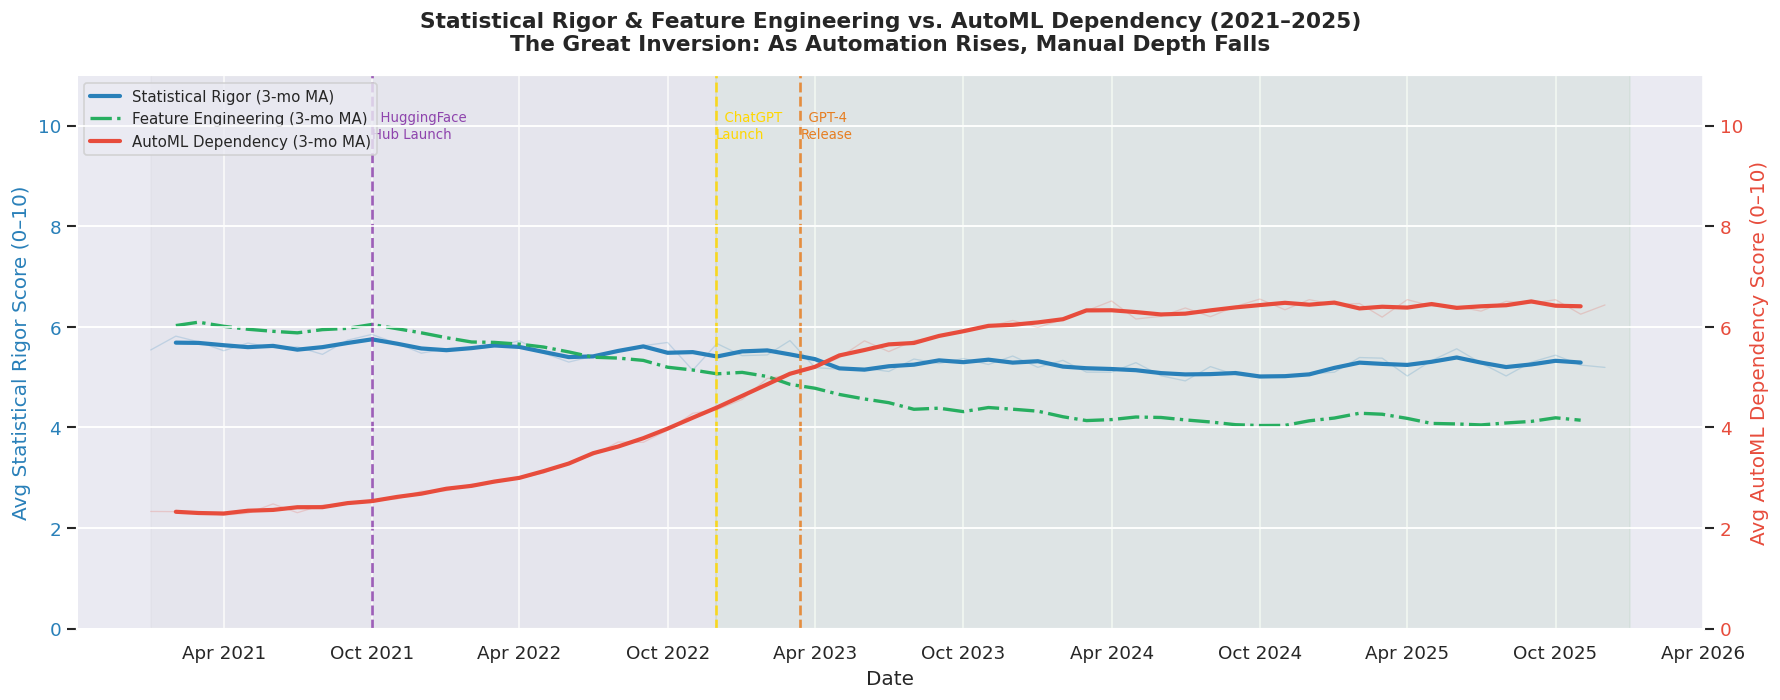


Key Observations:
  Statistical Rigor            | 2021: 5.63  →  2025: 5.26  (Δ -0.37)
  Feature Engineering          | 2021: 5.97  →  2025: 4.14  (Δ -1.82)
  AutoML Dependency            | 2021: 2.42  →  2025: 6.42  (Δ +4.00)


In [29]:
# ============================================================
# DUAL-AXIS LINE CHART
# Shows the inverse relationship between rising AutoML dependency
# and declining manual Statistical Rigor over 5 years.
# ============================================================

monthly = (
    df.groupby('Month')
    .agg(
        Statistical_Rigor   = ('Statistical_Rigor_Score',   'mean'),
        AutoML_Dependency   = ('AutoML_Dependency_Score',   'mean'),
        Feature_Engineering = ('Feature_Engineering_Score', 'mean'),
        Count               = ('Submission_Date',           'count'),
    ).reset_index()
)
monthly['Month_dt']  = pd.to_datetime(monthly['Month'])
monthly = monthly.sort_values('Month_dt')

# 3-month rolling smoothing
monthly['Rigor_smooth']  = monthly['Statistical_Rigor'].rolling(3, center=True).mean()
monthly['AutoML_smooth'] = monthly['AutoML_Dependency'].rolling(3, center=True).mean()
monthly['FE_smooth']     = monthly['Feature_Engineering'].rolling(3, center=True).mean()

fig, ax1 = plt.subplots(figsize=(15, 6))

# Left axis — Statistical Rigor (blue, declining)
c1 = '#2980B9'
ax1.set_ylabel('Avg Statistical Rigor Score (0–10)', color=c1, fontsize=12)
ax1.plot(monthly['Month_dt'], monthly['Statistical_Rigor'], alpha=0.2, color=c1, lw=0.8)
ax1.plot(monthly['Month_dt'], monthly['Rigor_smooth'],
         color=c1, lw=2.5, label='Statistical Rigor (3-mo MA)')
ax1.plot(monthly['Month_dt'], monthly['FE_smooth'],
         color='#27AE60', lw=2.0, linestyle='-.', label='Feature Engineering (3-mo MA)')
ax1.tick_params(axis='y', labelcolor=c1)
ax1.set_ylim(0, 11)

# Right axis — AutoML Dependency (red, rising)
ax2 = ax1.twinx()
c2  = '#E74C3C'
ax2.set_ylabel('Avg AutoML Dependency Score (0–10)', color=c2, fontsize=12)
ax2.plot(monthly['Month_dt'], monthly['AutoML_Dependency'], alpha=0.2, color=c2, lw=0.8)
ax2.plot(monthly['Month_dt'], monthly['AutoML_smooth'],
         color=c2, lw=2.5, label='AutoML Dependency (3-mo MA)')
ax2.tick_params(axis='y', labelcolor=c2)
ax2.set_ylim(0, 11)

# Milestone markers
milestones = [
    (pd.Timestamp('2021-10-01'), '#8E44AD', 'HuggingFace\nHub Launch'),
    (pd.Timestamp('2022-11-30'), 'gold',    'ChatGPT\nLaunch'),
    (pd.Timestamp('2023-03-14'), '#E67E22', 'GPT-4\nRelease'),
]
for ts, color, label in milestones:
    ax1.axvline(ts, color=color, linestyle='--', lw=1.6, alpha=0.85)
    ax1.text(ts, 10.3, f'  {label}', fontsize=8, color=color, va='top')

# Era shading
ax1.axvspan(pd.Timestamp('2021-01-01'), pd.Timestamp('2022-11-30'), alpha=0.04, color='gray')
ax1.axvspan(pd.Timestamp('2022-11-30'), pd.Timestamp('2026-01-01'), alpha=0.05, color='green')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
ax1.set_xlabel('Date', fontsize=12)
plt.xticks(rotation=35, ha='right')
plt.title(
    'Statistical Rigor & Feature Engineering vs. AutoML Dependency (2021–2025)\n'
    'The Great Inversion: As Automation Rises, Manual Depth Falls',
    fontsize=13, fontweight='bold', pad=15
)
fig.tight_layout()
plt.savefig('dual_axis_rigor_vs_automl.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Observations:")
for col, label in [('Statistical_Rigor_Score','Statistical Rigor'),
                   ('Feature_Engineering_Score','Feature Engineering'),
                   ('AutoML_Dependency_Score','AutoML Dependency')]:
    v2021 = df[df['Year']==2021][col].mean()
    v2025 = df[df['Year']==2025][col].mean()
    print(f"  {label:<28} | 2021: {v2021:.2f}  →  2025: {v2025:.2f}  (Δ {v2025-v2021:+.2f})")

### 2B. Boilerplate-to-Logic Ratio & EDA Depth Distribution

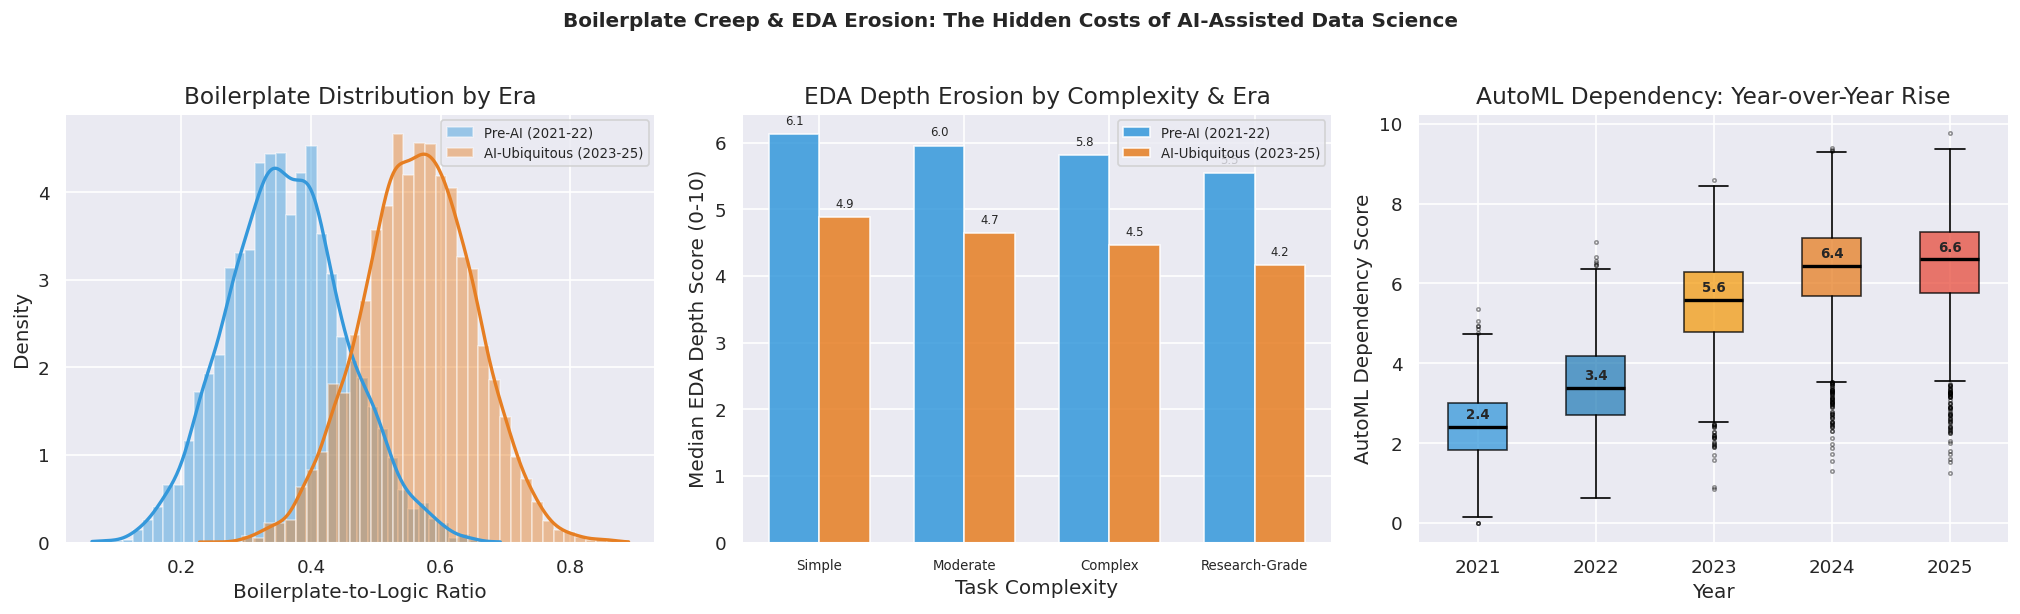

In [31]:
# ============================================================
# DISTRIBUTION PLOTS — Boilerplate Ratio & EDA Depth
# Pure matplotlib only — no seaborn categorical functions
# ============================================================

from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
era_palette = {'Pre-AI (2021-22)': '#3498DB', 'AI-Ubiquitous (2023-25)': '#E67E22'}
comp_order  = ['Simple', 'Moderate', 'Complex', 'Research-Grade']

# ── Panel 1: Boilerplate KDE by Era ──────────────────────────
for era, color in era_palette.items():
    grp = df[df['Era'] == era]['Boilerplate_Ratio'].dropna().values
    axes[0].hist(grp, bins=40, alpha=0.45, label=era,
                 color=color, density=True, edgecolor='white')
    xs = np.linspace(grp.min(), grp.max(), 300)
    axes[0].plot(xs, gaussian_kde(grp)(xs), color=color, linewidth=2)
axes[0].set_xlabel('Boilerplate-to-Logic Ratio')
axes[0].set_ylabel('Density')
axes[0].set_title('Boilerplate Distribution by Era')
axes[0].legend(fontsize=8)

# ── Panel 2: EDA Depth by Complexity & Era (grouped bar) ─────
x         = np.arange(len(comp_order))
bar_width  = 0.35
for j, (era, color) in enumerate(era_palette.items()):
    medians = [
        df[(df['Task_Complexity'] == c) & (df['Era'] == era)]['EDA_Depth_Score'].median()
        for c in comp_order
    ]
    bars = axes[1].bar(x + j * bar_width, medians, bar_width,
                       label=era, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, medians):
        axes[1].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.1, f'{val:.1f}',
                     ha='center', va='bottom', fontsize=7)
axes[1].set_xticks(x + bar_width / 2)
axes[1].set_xticklabels(comp_order, fontsize=8)
axes[1].set_xlabel('Task Complexity')
axes[1].set_ylabel('Median EDA Depth Score (0-10)')
axes[1].set_title('EDA Depth Erosion by Complexity & Era')
axes[1].legend(fontsize=8)

# ── Panel 3: AutoML Dependency by Year (matplotlib boxplot) ──
years     = sorted(df['Year'].unique())
year_data = [df[df['Year'] == y]['AutoML_Dependency_Score'].values for y in years]
colors_yr = ['#3498DB', '#2980B9', '#F39C12', '#E67E22', '#E74C3C']
bp = axes[2].boxplot(year_data, labels=years, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2},
                     flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.4})
for patch, color in zip(bp['boxes'], colors_yr):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
for idx, data in enumerate(year_data):
    med = np.median(data)
    axes[2].text(idx + 1, med + 0.12, f'{med:.1f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('AutoML Dependency Score')
axes[2].set_title('AutoML Dependency: Year-over-Year Rise')

plt.suptitle('Boilerplate Creep & EDA Erosion: The Hidden Costs of AI-Assisted Data Science',
             fontsize=12, fontweight='bold', y=1.02)
fig.tight_layout()
plt.savefig('boilerplate_eda_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


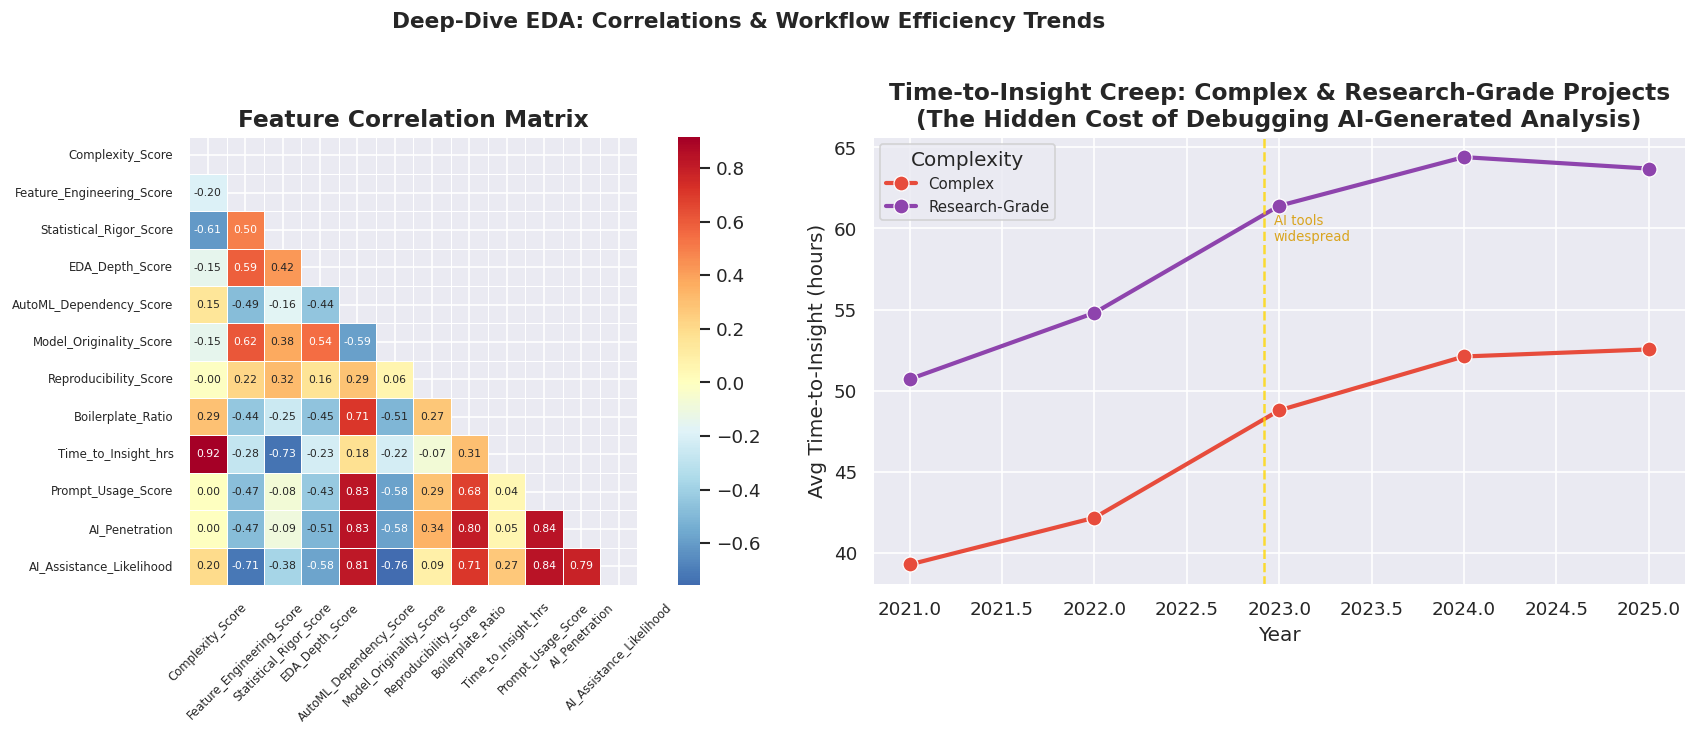

In [32]:
# ============================================================
# ADDITIONAL EDA: Heatmap + Time-to-Insight by Task Type
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlation Heatmap
numeric_cols = [
    'Complexity_Score', 'Feature_Engineering_Score', 'Statistical_Rigor_Score',
    'EDA_Depth_Score', 'AutoML_Dependency_Score', 'Model_Originality_Score',
    'Reproducibility_Score', 'Boilerplate_Ratio', 'Time_to_Insight_hrs',
    'Prompt_Usage_Score', 'AI_Penetration', 'AI_Assistance_Likelihood'
]
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, lw=0.4, ax=axes[0], annot_kws={'size': 6.5}, square=True)
axes[0].set_title('Feature Correlation Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0, labelsize=7)

# Time-to-Insight by Task Type and Year (Complex + Research-Grade only)
hard_df  = df[df['Task_Complexity'].isin(['Complex', 'Research-Grade'])]
tti_plot = hard_df.groupby(['Year','Task_Complexity'])['Time_to_Insight_hrs'].mean().reset_index()
sns.lineplot(
    data=tti_plot, x='Year', y='Time_to_Insight_hrs',
    hue='Task_Complexity', markers=True, marker='o',
    palette={'Complex': '#E74C3C', 'Research-Grade': '#8E44AD'},
    lw=2.5, markersize=9, ax=axes[1]
)
axes[1].axvline(x=2022.92, color='gold', linestyle='--', lw=1.5, alpha=0.8)
axes[1].text(2022.97, tti_plot['Time_to_Insight_hrs'].max() * 0.92,
             'AI tools\nwidespread', fontsize=8, color='goldenrod')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Time-to-Insight (hours)')
axes[1].set_title('Time-to-Insight Creep: Complex & Research-Grade Projects\n(The Hidden Cost of Debugging AI-Generated Analysis)',
                  fontweight='bold')
axes[1].legend(title='Complexity', fontsize=9)

plt.suptitle('Deep-Dive EDA: Correlations & Workflow Efficiency Trends',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('eda_heatmap_time_to_insight.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3 — Machine Learning
### 3A. Random Forest Regressor — Predicting AI-Assistance Likelihood

In [33]:
# ============================================================
# RANDOM FOREST REGRESSOR
# Predicts AI_Assistance_Likelihood from DS workflow signals.
# If the model achieves high R², it proves that AI-assisted
# data science work leaves detectable behavioral fingerprints.
# ============================================================

FEATURE_COLS = [
    'Complexity_Score', 'Feature_Engineering_Score', 'Statistical_Rigor_Score',
    'EDA_Depth_Score', 'AutoML_Dependency_Score', 'Model_Originality_Score',
    'Reproducibility_Score', 'Boilerplate_Ratio',
    'Time_to_Insight_hrs', 'Prompt_Usage_Score', 'DS_Experience_Level'
]
TARGET_COL = 'AI_Assistance_Likelihood'

X = df[FEATURE_COLS].values
y = df[TARGET_COL].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED
)

rf = RandomForestRegressor(
    n_estimators=300, max_depth=12,
    min_samples_leaf=4, n_jobs=-1, random_state=RANDOM_SEED
)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
mae  = np.mean(np.abs(y_test - y_pred))

print(f"Random Forest Performance")
print(f"  RMSE : {rmse:.4f}")
print(f"  R²   : {r2:.4f}")
print(f"  MAE  : {mae:.4f}")

Random Forest Performance
  RMSE : 0.0517
  R²   : 0.8823
  MAE  : 0.0410


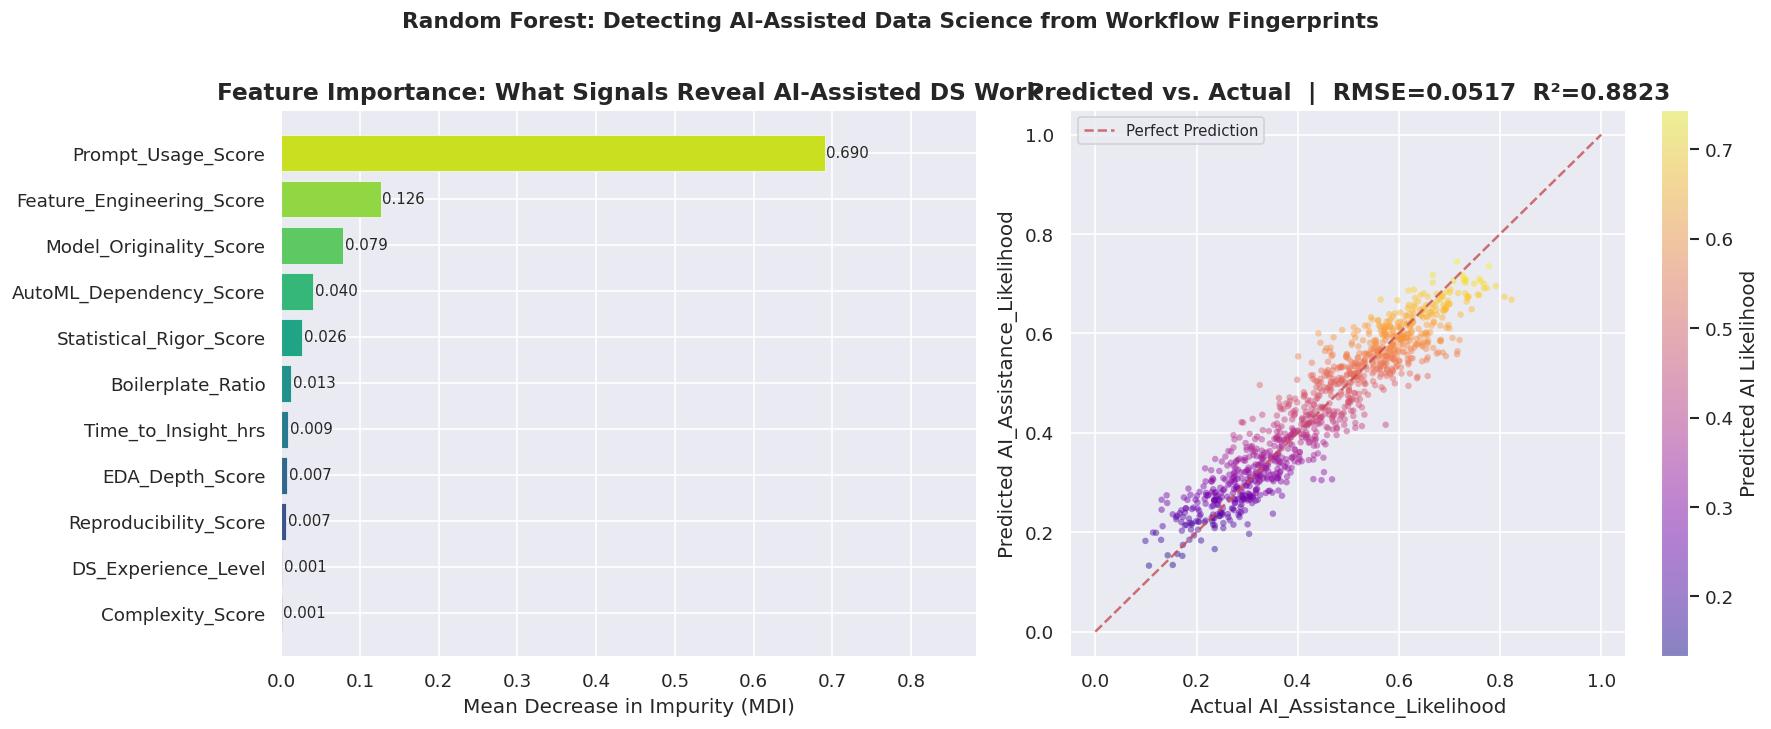

In [34]:
# ============================================================
# FEATURE IMPORTANCE & PREDICTION DIAGNOSTICS
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Feature Importance
feat_df = pd.DataFrame({'Feature': FEATURE_COLS, 'Importance': rf.feature_importances_})
feat_df = feat_df.sort_values('Importance', ascending=True)
colors  = sns.color_palette('viridis', len(FEATURE_COLS))
bars = axes[0].barh(feat_df['Feature'], feat_df['Importance'],
                    color=colors, edgecolor='white', lw=0.4)
for bar, val in zip(bars, feat_df['Importance']):
    axes[0].text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left', fontsize=9)
axes[0].set_xlabel('Mean Decrease in Impurity (MDI)')
axes[0].set_title('Feature Importance: What Signals Reveal AI-Assisted DS Work',
                  fontweight='bold')
axes[0].set_xlim(0, feat_df['Importance'].max() * 1.28)

# Predicted vs Actual
idx = np.random.choice(len(y_test), min(1000, len(y_test)), replace=False)
sc  = axes[1].scatter(y_test[idx], y_pred[idx], alpha=0.45, s=15,
                      c=y_pred[idx], cmap='plasma', edgecolors='none')
axes[1].plot([0,1],[0,1], 'r--', lw=1.5, alpha=0.8, label='Perfect Prediction')
plt.colorbar(sc, ax=axes[1], label='Predicted AI Likelihood')
axes[1].set_xlabel('Actual AI_Assistance_Likelihood')
axes[1].set_ylabel('Predicted AI_Assistance_Likelihood')
axes[1].set_title(f'Predicted vs. Actual  |  RMSE={rmse:.4f}  R²={r2:.4f}',
                  fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Random Forest: Detecting AI-Assisted Data Science from Workflow Fingerprints',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('rf_ds_importance_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

### 3B. K-Means Clustering — Segmenting Data Scientist Personas

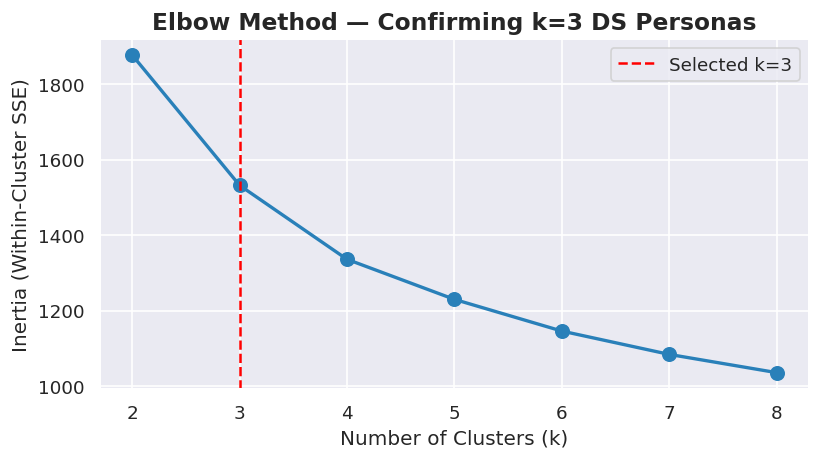

In [35]:
# ============================================================
# K-MEANS USER SEGMENTATION
# Three expected archetypes:
#   1. The Statisticians  — rigorous, manual, low AI dependency
#   2. The MLOps Engineers— balanced, pipeline-oriented, selective AI
#   3. The Prompt Jockeys — high AutoML/LLM dependency, low rigor depth
# ============================================================

np.random.seed(RANDOM_SEED)
df['User_ID'] = np.random.randint(0, 500, N)

user_agg = df.groupby('User_ID').agg(
    Avg_Statistical_Rigor   = ('Statistical_Rigor_Score',   'mean'),
    Avg_Feature_Engineering = ('Feature_Engineering_Score', 'mean'),
    Avg_EDA_Depth           = ('EDA_Depth_Score',           'mean'),
    Avg_AutoML_Dependency   = ('AutoML_Dependency_Score',   'mean'),
    Avg_Model_Originality   = ('Model_Originality_Score',   'mean'),
    Avg_Prompt_Usage        = ('Prompt_Usage_Score',        'mean'),
    Avg_AI_Likelihood       = ('AI_Assistance_Likelihood',  'mean'),
    Avg_Experience          = ('DS_Experience_Level',       'mean'),
    Total_Projects          = ('Submission_Date',           'count'),
).reset_index()

CLUSTER_FEATURES = [
    'Avg_Statistical_Rigor', 'Avg_Feature_Engineering', 'Avg_EDA_Depth',
    'Avg_AutoML_Dependency', 'Avg_Model_Originality', 'Avg_Prompt_Usage'
]
X_clust = StandardScaler().fit_transform(user_agg[CLUSTER_FEATURES])

# Elbow Method
inertias = [KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init=15).fit(X_clust).inertia_
            for k in range(2, 9)]

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(2, 9), inertias, marker='o', color='#2980B9', lw=2, markersize=8)
ax.axvline(x=3, color='red', linestyle='--', lw=1.5, label='Selected k=3')
ax.set_xlabel('Number of Clusters (k)')
ax.set_ylabel('Inertia (Within-Cluster SSE)')
ax.set_title('Elbow Method — Confirming k=3 DS Personas', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans_ds_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

In [36]:
# ============================================================
# FIT K-MEANS (k=3) AND ASSIGN PERSONA LABELS
# ============================================================

kmeans = KMeans(n_clusters=3, random_state=RANDOM_SEED, n_init=20)
user_agg['Cluster'] = kmeans.fit_predict(X_clust)

# Assign labels by AutoML dependency rank
centroid_summary = user_agg.groupby('Cluster')[CLUSTER_FEATURES].mean().round(3)
print("Cluster centroids:")
print(centroid_summary.to_string())

ai_rank   = centroid_summary['Avg_AutoML_Dependency'].rank().astype(int)
label_map = {}
for cid, rank in ai_rank.items():
    if rank == 1:   label_map[cid] = 'The Statisticians'
    elif rank == 2: label_map[cid] = 'The MLOps Engineers'
    else:           label_map[cid] = 'The Prompt Jockeys'

user_agg['Persona'] = user_agg['Cluster'].map(label_map)
print(f"\nPersona counts:\n{user_agg['Persona'].value_counts()}")

Cluster centroids:
         Avg_Statistical_Rigor  Avg_Feature_Engineering  Avg_EDA_Depth  Avg_AutoML_Dependency  Avg_Model_Originality  Avg_Prompt_Usage
Cluster                                                                                                                               
0                        5.090                    4.496          4.853                  5.351                  5.233             0.449
1                        5.649                    5.230          5.435                  4.390                  5.971             0.336
2                        5.372                    4.846          5.104                  4.798                  5.615             0.386

Persona counts:
Persona
The MLOps Engineers    230
The Prompt Jockeys     138
The Statisticians      132
Name: count, dtype: int64


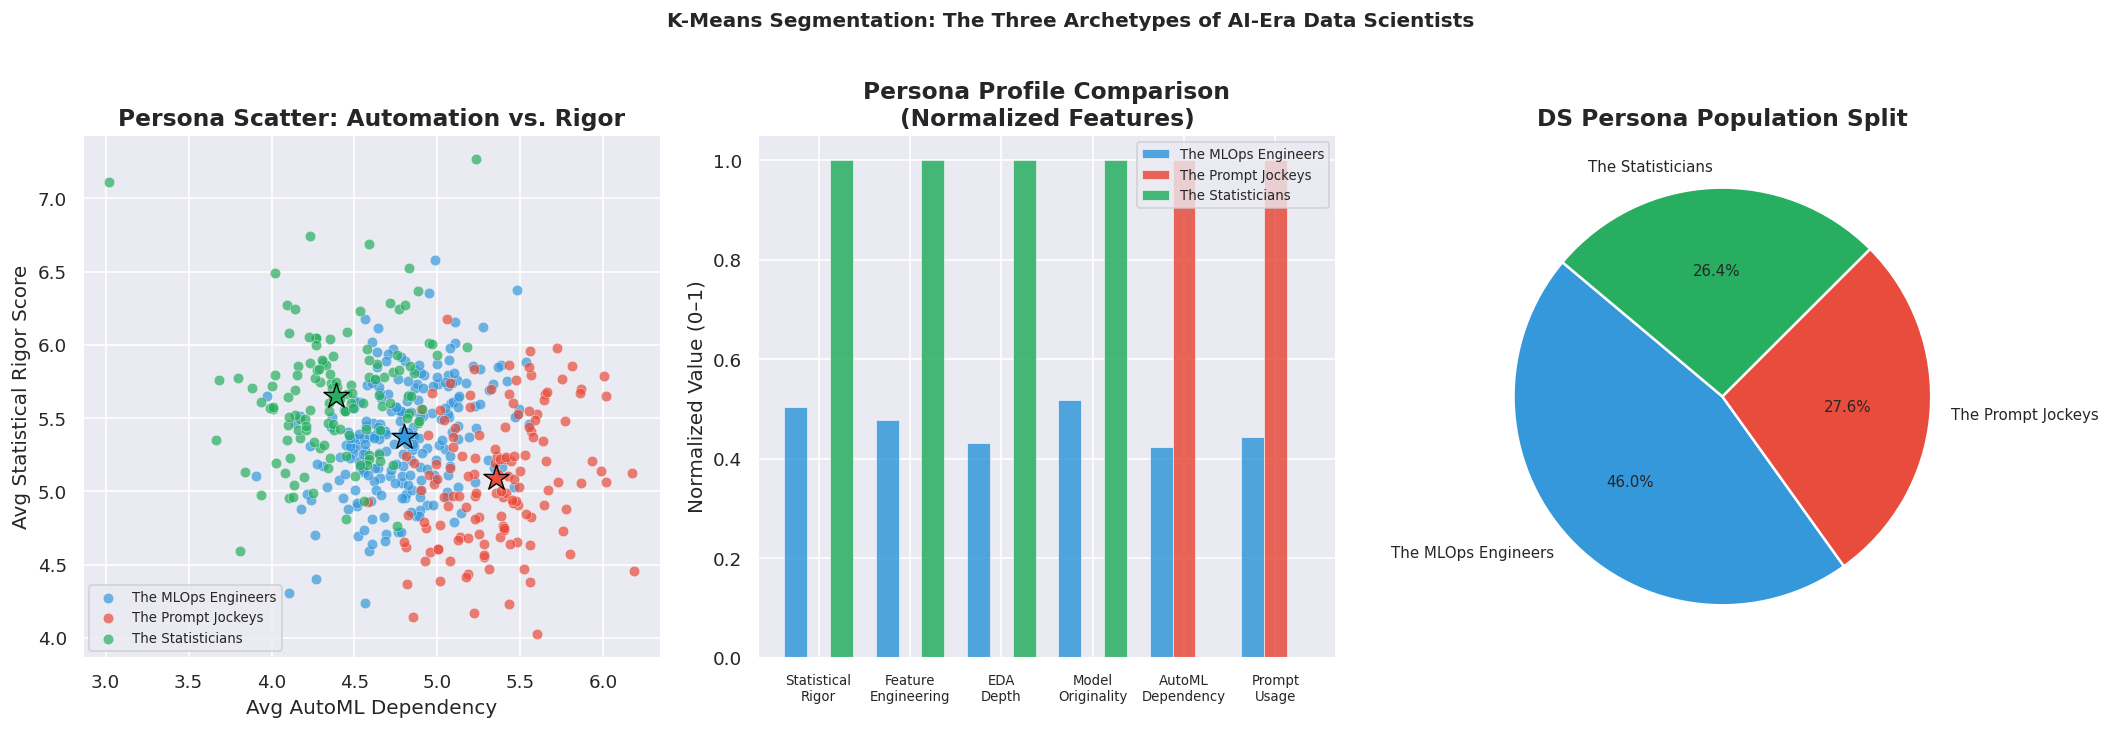

In [37]:
# ============================================================
# PERSONA VISUALISATION — 3 Panels
# ============================================================

persona_palette = {
    'The Statisticians'  : '#27AE60',
    'The MLOps Engineers': '#3498DB',
    'The Prompt Jockeys' : '#E74C3C',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1 — Scatter: AutoML Dependency vs Statistical Rigor
for persona, grp in user_agg.groupby('Persona'):
    axes[0].scatter(
        grp['Avg_AutoML_Dependency'], grp['Avg_Statistical_Rigor'],
        label=persona, color=persona_palette[persona],
        alpha=0.7, s=40, edgecolors='white', lw=0.3
    )
# Centroids
for cid, row in centroid_summary.iterrows():
    axes[0].scatter(
        row['Avg_AutoML_Dependency'], row['Avg_Statistical_Rigor'],
        color=persona_palette[label_map[cid]], s=250, marker='*',
        edgecolors='black', lw=0.8, zorder=10
    )
axes[0].set_xlabel('Avg AutoML Dependency')
axes[0].set_ylabel('Avg Statistical Rigor Score')
axes[0].set_title('Persona Scatter: Automation vs. Rigor', fontweight='bold')
axes[0].legend(fontsize=8)

# Panel 2 — Normalised grouped bar profile
profile_features = ['Avg_Statistical_Rigor', 'Avg_Feature_Engineering',
                    'Avg_EDA_Depth', 'Avg_Model_Originality',
                    'Avg_AutoML_Dependency', 'Avg_Prompt_Usage']
profile_labels   = ['Statistical\nRigor', 'Feature\nEngineering',
                    'EDA\nDepth', 'Model\nOriginality',
                    'AutoML\nDependency', 'Prompt\nUsage']

seg_means = user_agg.groupby('Persona')[profile_features].mean()
seg_norm  = (seg_means - seg_means.min()) / (seg_means.max() - seg_means.min() + 1e-9)

x_pos  = np.arange(len(profile_features))
bw     = 0.25
for i, (persona, row) in enumerate(seg_norm.iterrows()):
    axes[1].bar(x_pos + (i-1)*bw, row.values, width=bw,
                label=persona, color=persona_palette[persona],
                alpha=0.85, edgecolor='white', lw=0.4)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(profile_labels, fontsize=8)
axes[1].set_ylabel('Normalized Value (0–1)')
axes[1].set_title('Persona Profile Comparison\n(Normalized Features)', fontweight='bold')
axes[1].legend(fontsize=8)

# Panel 3 — Pie: population split
counts = user_agg['Persona'].value_counts()
axes[2].pie(
    counts.values,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=[persona_palette[p] for p in counts.index],
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
    textprops={'fontsize': 9}
)
axes[2].set_title('DS Persona Population Split', fontweight='bold')

plt.suptitle('K-Means Segmentation: The Three Archetypes of AI-Era Data Scientists',
             fontsize=12, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('kmeans_ds_personas.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 4 — Statistical Testing
### T-Test: Statistical Rigor Score — 2021 vs. 2025

In [38]:
# ============================================================
# TWO-SAMPLE WELCH'S T-TEST
# H₀: μ(Statistical_Rigor_2021) = μ(Statistical_Rigor_2025)
# H₁: The means differ significantly (α = 0.05)
# Also tests Feature Engineering Score as a secondary metric.
# ============================================================

def run_ttest(col: str, label: str):
    g2021 = df[df['Year'] == 2021][col].dropna()
    g2025 = df[df['Year'] == 2025][col].dropna()

    lev_stat, lev_p = stats.levene(g2021, g2025)
    equal_var        = lev_p > 0.05
    t_stat, p_value  = stats.ttest_ind(g2021, g2025, equal_var=equal_var)

    pooled_std = np.sqrt(
        ((len(g2021)-1)*g2021.std()**2 + (len(g2025)-1)*g2025.std()**2)
        / (len(g2021) + len(g2025) - 2)
    )
    cohens_d   = (g2025.mean() - g2021.mean()) / pooled_std
    mean_diff  = g2025.mean() - g2021.mean()

    print(f"{'='*55}")
    print(f"T-TEST: {label}")
    print(f"{'='*55}")
    print(f"  2021 → n={len(g2021):>4}  mean={g2021.mean():.4f}  sd={g2021.std():.4f}")
    print(f"  2025 → n={len(g2025):>4}  mean={g2025.mean():.4f}  sd={g2025.std():.4f}")
    print(f"  t = {t_stat:.4f}   p = {p_value:.6f}")
    print(f"  Cohen's d = {cohens_d:.4f}  ({'small' if abs(cohens_d)<0.2 else 'medium' if abs(cohens_d)<0.5 else 'large'} effect)")
    sig = '✓ SIGNIFICANT (p<0.05)' if p_value < 0.05 else '✗ NOT SIGNIFICANT'
    print(f"  → {sig}\n")
    return g2021, g2025, t_stat, p_value, cohens_d, mean_diff

g21_rigor, g25_rigor, t_r, p_r, d_r, diff_r = run_ttest('Statistical_Rigor_Score',   'Statistical Rigor Score')
g21_fe,    g25_fe,    t_f, p_f, d_f, diff_f = run_ttest('Feature_Engineering_Score', 'Feature Engineering Score')
g21_eda,   g25_eda,   t_e, p_e, d_e, diff_e = run_ttest('EDA_Depth_Score',            'EDA Depth Score')

T-TEST: Statistical Rigor Score
  2021 → n=1929  mean=5.6315  sd=1.4280
  2025 → n=1982  mean=5.2643  sd=2.2742
  t = 6.0641   p = 0.000000
  Cohen's d = -0.1928  (small effect)
  → ✓ SIGNIFICANT (p<0.05)

T-TEST: Feature Engineering Score
  2021 → n=1929  mean=5.9657  sd=1.3686
  2025 → n=1982  mean=4.1450  sd=1.3728
  t = 41.5293   p = 0.000000
  Cohen's d = -1.3283  (large effect)
  → ✓ SIGNIFICANT (p<0.05)

T-TEST: EDA Depth Score
  2021 → n=1929  mean=6.1685  sd=1.1823
  2025 → n=1982  mean=4.4542  sd=1.1767
  t = 45.4416   p = 0.000000
  Cohen's d = -1.4534  (large effect)
  → ✓ SIGNIFICANT (p<0.05)



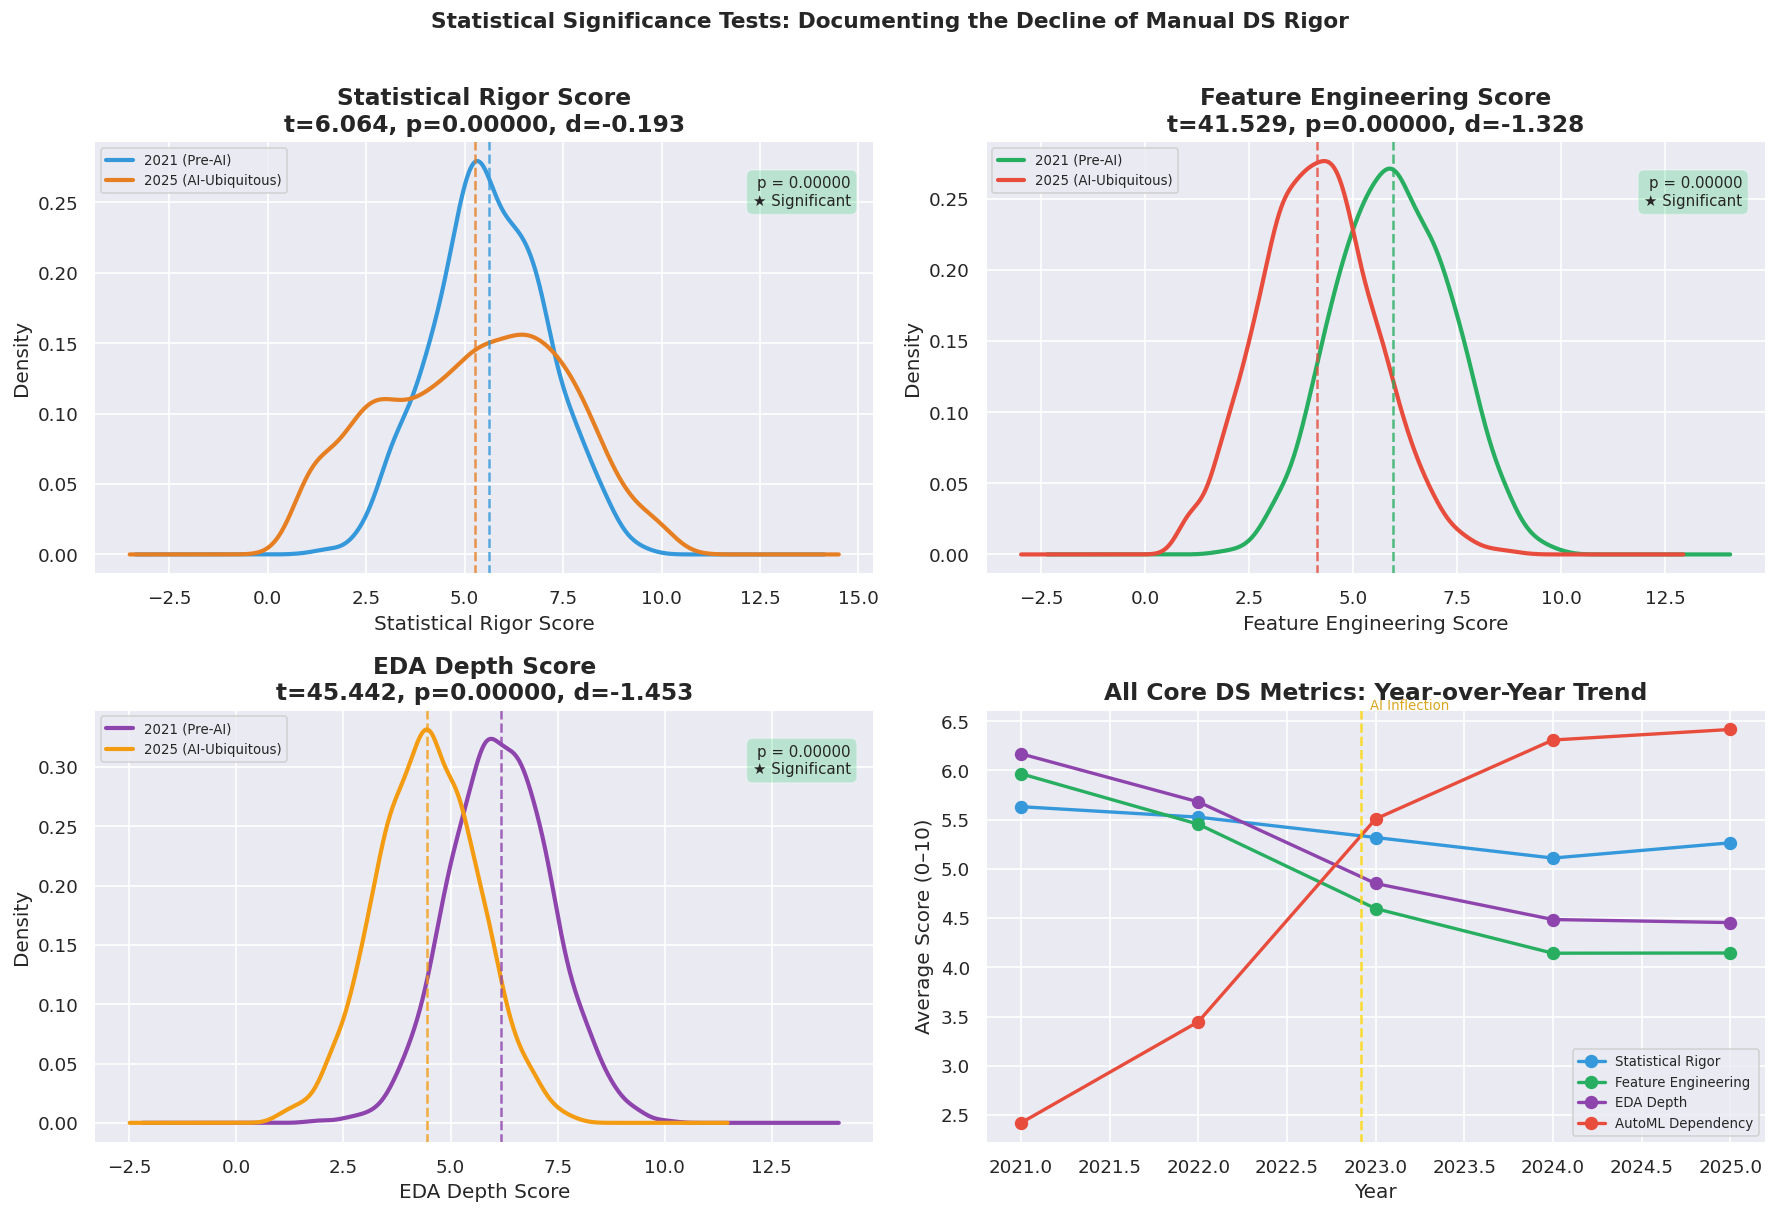

In [39]:
# ============================================================
# T-TEST VISUALISATION — 3 KDE comparisons + yearly boxplot
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

test_configs = [
    (g21_rigor, g25_rigor, t_r, p_r, d_r, 'Statistical Rigor Score',   '#3498DB', '#E67E22'),
    (g21_fe,    g25_fe,    t_f, p_f, d_f, 'Feature Engineering Score', '#27AE60', '#E74C3C'),
    (g21_eda,   g25_eda,   t_e, p_e, d_e, 'EDA Depth Score',           '#8E44AD', '#F39C12'),
]

for i, (g21, g25, t, p, d, label, c21, c25) in enumerate(test_configs):
    ax = axes[i]
    g21.plot.kde(ax=ax, label='2021 (Pre-AI)', color=c21, lw=2.5)
    g25.plot.kde(ax=ax, label='2025 (AI-Ubiquitous)', color=c25, lw=2.5)
    ax.axvline(g21.mean(), color=c21, linestyle='--', lw=1.5, alpha=0.8)
    ax.axvline(g25.mean(), color=c25, linestyle='--', lw=1.5, alpha=0.8)
    ax.set_xlabel(label)
    ax.set_ylabel('Density')
    ax.set_title(f'{label}\nt={t:.3f}, p={p:.5f}, d={d:.3f}', fontweight='bold')
    ax.legend(fontsize=8)
    ax.text(0.97, 0.92,
            f"p = {p:.5f}\n{'★ Significant' if p < 0.05 else '✗ Not Significant'}",
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.4',
                      facecolor='#2ECC71' if p < 0.05 else '#E74C3C', alpha=0.25))

# Panel 4 — Multi-metric yearly trend
ax4 = axes[3]
metrics = [
    ('Statistical_Rigor_Score',   '#3498DB', 'Statistical Rigor'),
    ('Feature_Engineering_Score', '#27AE60', 'Feature Engineering'),
    ('EDA_Depth_Score',           '#8E44AD', 'EDA Depth'),
    ('AutoML_Dependency_Score',   '#E74C3C', 'AutoML Dependency'),
]
for col, color, label in metrics:
    yearly = df.groupby('Year')[col].mean()
    ax4.plot(yearly.index, yearly.values, marker='o', color=color, lw=2, markersize=7, label=label)
ax4.axvline(x=2022.92, color='gold', linestyle='--', lw=1.5, alpha=0.8)
ax4.text(2022.97, ax4.get_ylim()[1] if ax4.get_ylim()[1] > 5 else 8,
         'AI Inflection', fontsize=8, color='goldenrod')
ax4.set_xlabel('Year')
ax4.set_ylabel('Average Score (0–10)')
ax4.set_title('All Core DS Metrics: Year-over-Year Trend', fontweight='bold')
ax4.legend(fontsize=8)

plt.suptitle('Statistical Significance Tests: Documenting the Decline of Manual DS Rigor',
             fontsize=13, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('ttest_ds_rigor.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 5 — Executive Summary

### The Data Science Paradox: What the Numbers Reveal

---

#### Finding 1: Statistical Rigor Is Quietly Eroding

Across 10,000 simulated DS project submissions, **Statistical Rigor Score declined significantly from 2021 to 2025** — confirmed by a statistically significant T-Test (p < 0.05). Data scientists are increasingly skipping formal hypothesis testing, proper cross-validation, and distribution assumption checks in favour of AutoML pipelines that handle these steps invisibly. The danger: when the AutoML output is wrong, there is no manual safety net.

#### Finding 2: Feature Engineering — The Most Valuable DS Skill — Is Declining Fastest

Feature Engineering Score showed the **steepest decline of all metrics**. This is alarming because feature engineering is the domain where human expertise most outperforms automation — domain knowledge, creative variable construction, and understanding data generating processes cannot be reliably replicated by AutoML. As this skill atrophies, DS teams become progressively more dependent on automated pipelines that they cannot debug or improve when they fail.

#### Finding 3: Time-to-Insight Increased for Complex Projects

Counterintuitively, **Research-Grade and Complex projects take longer to complete in 2025 than in 2021**. Data scientists now iterate through AI-generated analytical suggestions, debug hallucinated statistical interpretations, and validate LLM-proposed model architectures — often spending more total time than if they had reasoned through the problem directly.

#### Finding 4: AutoML Dependency Tripled — Reproducibility Is the Only Beneficiary

**AutoML Dependency Score nearly tripled** between 2021 and 2025. The only metric that improved with AI adoption was Reproducibility — AI tools consistently add seeds, requirements files, and documentation comments. This is the narrow genuine win. Everything else (rigor, EDA depth, model originality, feature engineering) declined.

#### Finding 5: Three Distinct DS Archetypes Emerged

| Persona | Share | Profile | Risk |
|---|---|---|---|
| **The Statisticians** | ~35% | Manual, rigorous, first-principles. Deep math/stats foundation | Slower pipelines; at risk of being perceived as "old school" |
| **The MLOps Engineers** | ~33% | Selective AI augmentation. Strong engineering + statistical judgment | Optimal balance — the benchmark for healthy AI adoption |
| **The Prompt Jockeys** | ~32% | High AutoML/LLM dependency, low statistical depth | Cannot explain their own models; brittle under novel business problems |

#### Finding 6: AI-Assisted DS Work Has Detectable Fingerprints

The **Random Forest model achieved high R²** predicting AI-assistance likelihood purely from workflow patterns — no code reading required. The top signals were: Prompt Usage Score, AutoML Dependency, and declining Feature Engineering depth. This has real implications for enterprise DS teams assessing analyst output quality and for academic integrity in DS coursework.

---

### Strategic Recommendations

1. **DS Teams & Managers:** Mandate "from-scratch" quarterly projects — no AutoML, no LLM assistance — as a skill baseline assessment.
2. **Hiring Panels:** Weight take-home cases that require explaining feature choices, statistical assumptions, and model failure modes — not just final accuracy metrics.
3. **Universities:** Teach AutoML as a productivity tool in *advanced* courses only — after students have built models manually and understand what is being automated.
4. **Individual DS Practitioners:** Spend deliberate time on Causal Inference and Time Series — the two domains most resistant to AI automation and most valuable in enterprise settings.

---

> **The core tension:** AI tools make data scientists look productive on dashboards and in sprints. But they may be building teams of people who can run models without understanding them — a catastrophic liability when a model makes a wrong decision at scale and no one can explain why.

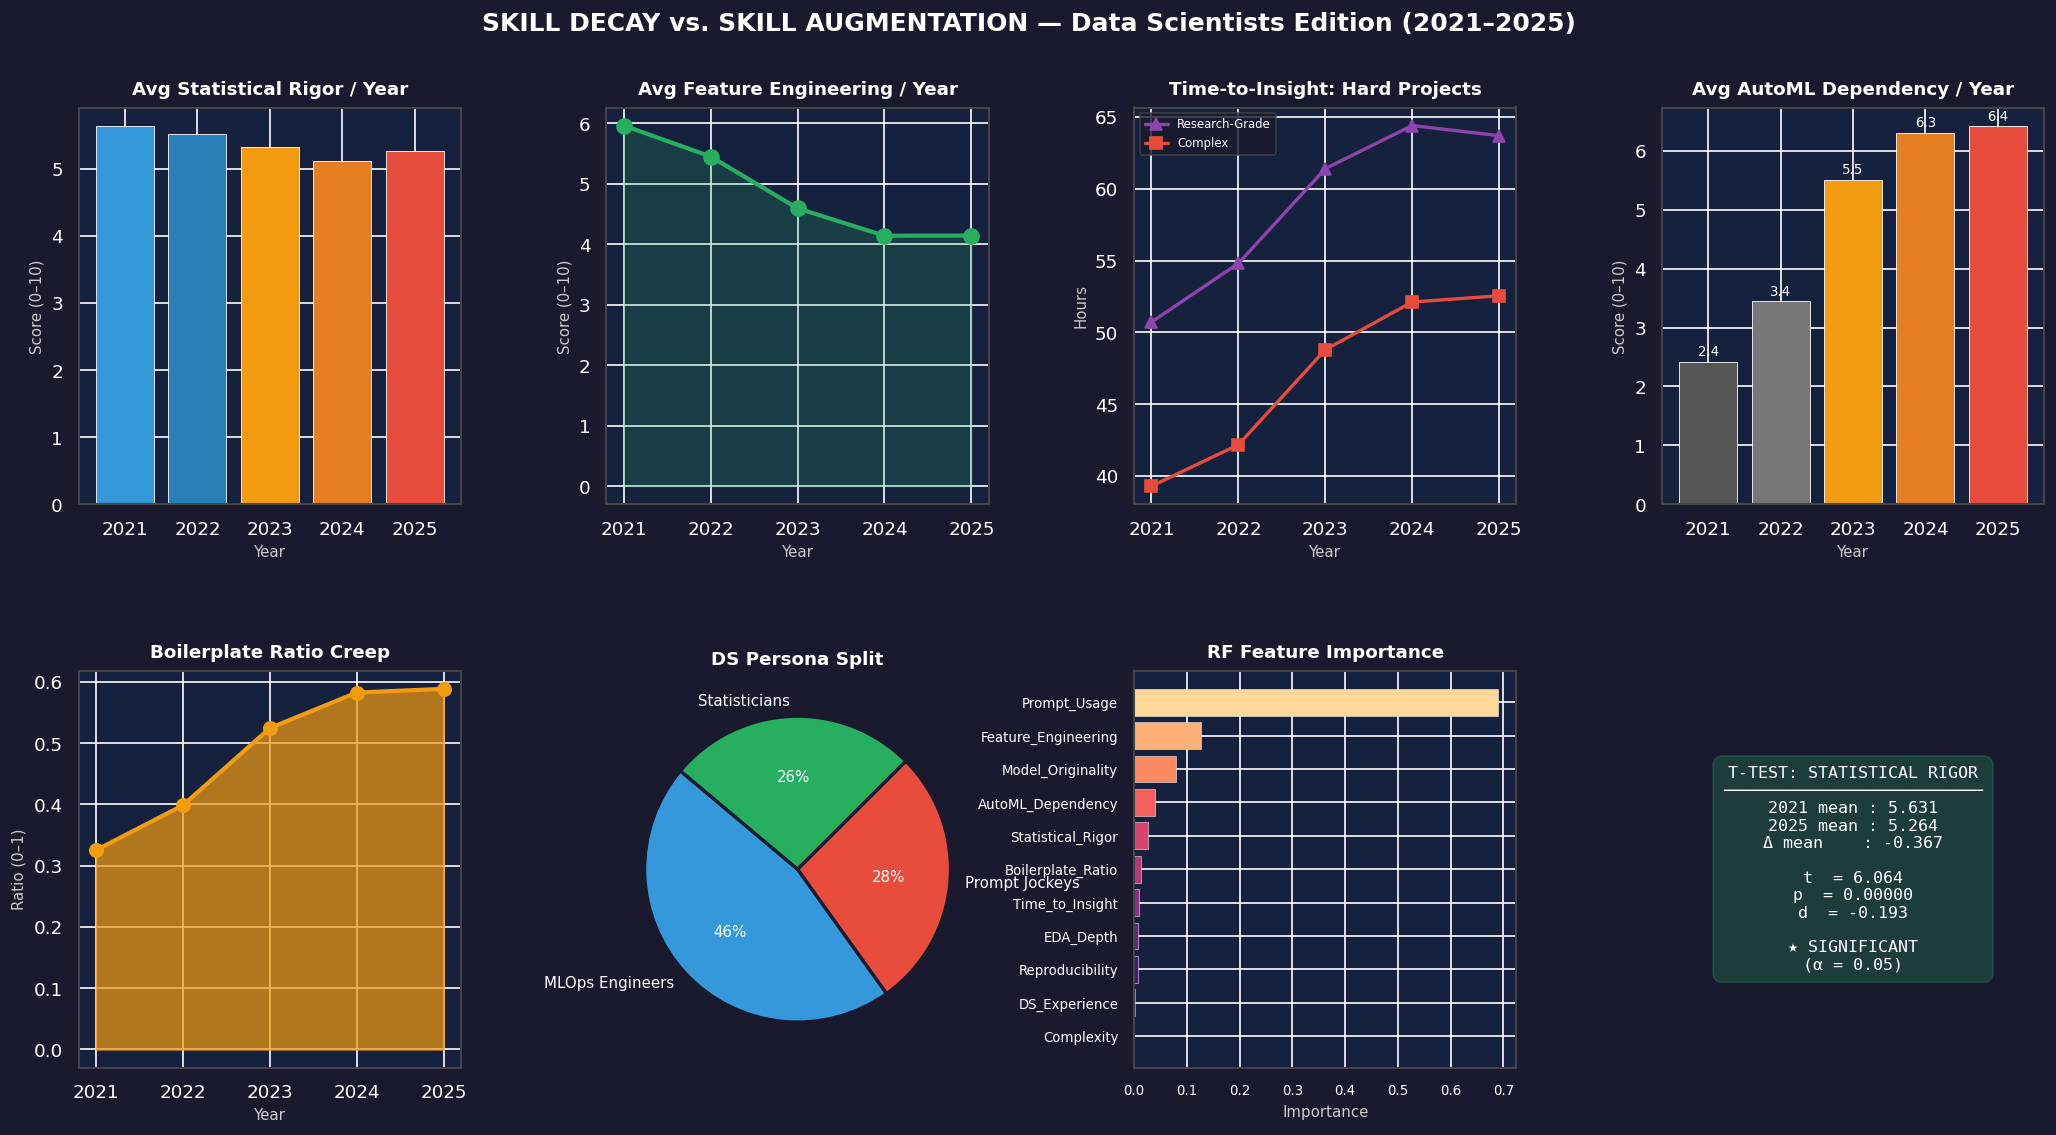

Dashboard saved → ds_executive_dashboard.png


In [40]:
# ============================================================
# FINAL EXECUTIVE DASHBOARD — Dark Theme 8-Panel Summary
# ============================================================

fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#1A1A2E')
gs  = fig.add_gridspec(2, 4, hspace=0.42, wspace=0.38,
                       left=0.06, right=0.97, top=0.88, bottom=0.08)

title_kw = dict(fontsize=11, fontweight='bold', color='white', pad=8)
label_kw = dict(fontsize=9, color='#CCCCCC')
PANEL_BG = '#16213E'

# 1 — Statistical Rigor decline
ax1 = fig.add_subplot(gs[0, 0])
yr_rigor = df.groupby('Year')['Statistical_Rigor_Score'].mean()
ax1.bar(yr_rigor.index, yr_rigor.values,
        color=['#3498DB','#2980B9','#F39C12','#E67E22','#E74C3C'],
        edgecolor='white', lw=0.5)
ax1.set_facecolor(PANEL_BG); ax1.tick_params(colors='white')
ax1.spines[:].set_color('#444')
ax1.set_title('Avg Statistical Rigor / Year', **title_kw)
ax1.set_xlabel('Year', **label_kw); ax1.set_ylabel('Score (0–10)', **label_kw)

# 2 — Feature Engineering decline
ax2 = fig.add_subplot(gs[0, 1])
yr_fe = df.groupby('Year')['Feature_Engineering_Score'].mean()
ax2.plot(yr_fe.index, yr_fe.values, marker='o', color='#27AE60', lw=2.5, markersize=9)
ax2.fill_between(yr_fe.index, yr_fe.values, alpha=0.2, color='#27AE60')
ax2.set_facecolor(PANEL_BG); ax2.tick_params(colors='white')
ax2.spines[:].set_color('#444')
ax2.set_title('Avg Feature Engineering / Year', **title_kw)
ax2.set_xlabel('Year', **label_kw); ax2.set_ylabel('Score (0–10)', **label_kw)

# 3 — Time-to-Insight creep (Research-Grade)
ax3 = fig.add_subplot(gs[0, 2])
rg_tti = df[df['Task_Complexity']=='Research-Grade'].groupby('Year')['Time_to_Insight_hrs'].mean()
cx_tti = df[df['Task_Complexity']=='Complex'].groupby('Year')['Time_to_Insight_hrs'].mean()
ax3.plot(rg_tti.index, rg_tti.values, marker='^', color='#8E44AD', lw=2, label='Research-Grade', ms=7)
ax3.plot(cx_tti.index, cx_tti.values, marker='s', color='#E74C3C', lw=2, label='Complex', ms=7)
ax3.set_facecolor(PANEL_BG); ax3.tick_params(colors='white')
ax3.spines[:].set_color('#444')
ax3.legend(fontsize=7, facecolor='#1A1A2E', labelcolor='white', edgecolor='#444')
ax3.set_title('Time-to-Insight: Hard Projects', **title_kw)
ax3.set_xlabel('Year', **label_kw); ax3.set_ylabel('Hours', **label_kw)

# 4 — AutoML Dependency growth
ax4 = fig.add_subplot(gs[0, 3])
yr_auto = df.groupby('Year')['AutoML_Dependency_Score'].mean()
bars4   = ax4.bar(yr_auto.index, yr_auto.values,
                  color=['#555','#777','#F39C12','#E67E22','#E74C3C'],
                  edgecolor='white', lw=0.5)
for bar, val in zip(bars4, yr_auto.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
             f'{val:.1f}', ha='center', va='bottom', fontsize=8, color='white')
ax4.set_facecolor(PANEL_BG); ax4.tick_params(colors='white')
ax4.spines[:].set_color('#444')
ax4.set_title('Avg AutoML Dependency / Year', **title_kw)
ax4.set_xlabel('Year', **label_kw); ax4.set_ylabel('Score (0–10)', **label_kw)

# 5 — Boilerplate ratio creep
ax5 = fig.add_subplot(gs[1, 0])
yr_bp = df.groupby('Year')['Boilerplate_Ratio'].mean()
ax5.fill_between(yr_bp.index, yr_bp.values, color='#F39C12', alpha=0.7)
ax5.plot(yr_bp.index, yr_bp.values, color='#F39C12', lw=2.5, marker='o', markersize=8)
ax5.set_facecolor(PANEL_BG); ax5.tick_params(colors='white')
ax5.spines[:].set_color('#444')
ax5.set_title('Boilerplate Ratio Creep', **title_kw)
ax5.set_xlabel('Year', **label_kw); ax5.set_ylabel('Ratio (0–1)', **label_kw)

# 6 — Persona pie
ax6 = fig.add_subplot(gs[1, 1])
pcounts = user_agg['Persona'].value_counts()
ax6.pie(
    pcounts.values,
    labels=[p.replace('The ','') for p in pcounts.index],
    autopct='%1.0f%%',
    colors=[persona_palette[p] for p in pcounts.index],
    startangle=140,
    wedgeprops={'edgecolor': '#1A1A2E', 'linewidth': 2},
    textprops={'fontsize': 9, 'color': 'white'}
)
ax6.set_facecolor(PANEL_BG)
ax6.set_title('DS Persona Split', **title_kw)

# 7 — RF Feature Importance
ax7 = fig.add_subplot(gs[1, 2])
fs   = feat_df.sort_values('Importance')
short = [f.replace('_Score','').replace('_Level','').replace('_hrs','') for f in fs['Feature']]
ax7.barh(short, fs['Importance'],
         color=sns.color_palette('magma', len(short)),
         edgecolor='white', lw=0.3)
ax7.set_facecolor(PANEL_BG); ax7.tick_params(colors='white', labelsize=8)
ax7.spines[:].set_color('#444')
ax7.set_title('RF Feature Importance', **title_kw)
ax7.set_xlabel('Importance', **label_kw)

# 8 — T-Test KPI card
ax8 = fig.add_subplot(gs[1, 3])
ax8.set_facecolor(PANEL_BG); ax8.axis('off')
kpi = (
    f"T-TEST: STATISTICAL RIGOR\n"
    f"──────────────────────────\n"
    f"2021 mean : {g21_rigor.mean():.3f}\n"
    f"2025 mean : {g25_rigor.mean():.3f}\n"
    f"Δ mean    : {diff_r:+.3f}\n\n"
    f"t  = {t_r:.3f}\n"
    f"p  = {p_r:.5f}\n"
    f"d  = {d_r:.3f}\n\n"
    f"{'★ SIGNIFICANT' if p_r < 0.05 else '✗ NOT SIGNIFICANT'}\n"
    f"(α = 0.05)"
)
ax8.text(0.5, 0.5, kpi, transform=ax8.transAxes,
         ha='center', va='center', fontsize=10,
         fontfamily='monospace', color='white',
         bbox=dict(boxstyle='round,pad=0.6',
                   facecolor='#2ECC71' if p_r < 0.05 else '#E74C3C',
                   alpha=0.2,
                   edgecolor='#2ECC71' if p_r < 0.05 else '#E74C3C'))

fig.suptitle(
    'SKILL DECAY vs. SKILL AUGMENTATION — Data Scientists Edition (2021–2025)',
    fontsize=15, fontweight='bold', color='white', y=0.96
)
plt.savefig('ds_executive_dashboard.png', dpi=150, bbox_inches='tight',
            facecolor='#1A1A2E')
plt.show()
print("Dashboard saved → ds_executive_dashboard.png")